# Model Explainability

## Objective

This notebook investigates how the selected production forecasting model generates its predictions using SHAP (SHapley Additive exPlanations).

The objectives are to:

- quantify the contribution of each engineered feature,
- identify the most influential predictors,
- explain individual model predictions,
- validate whether the learned relationships align with domain knowledge in renewable energy forecasting.

Unlike feature importance scores, SHAP provides both global and local explanations while maintaining consistency across model predictions.

## Imports

In [21]:
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
from pathlib import Path

In [16]:
DB_PATH = "../gridsight.duckdb"

TRAIN_END_DATE = "2025-12-31 23:00:00"
TEST_START_DATE = "2026-01-01 00:00:00"
TEST_END_DATE = "2026-06-30 23:00:00"

TARGET = "solar_generation_mw"

RANDOM_STATE = 42

EXPERIMENTS_DIR = Path("../experiments")
MODELS_DIR = Path("../models")

EXPERIMENTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

## Load Production Model

In [17]:
production_model = joblib.load(
    "../notebooks/models/production_model.joblib"
)

## Load Dataset

In [18]:
with duckdb.connect(DB_PATH) as con:
    df = con.sql("""
        SELECT *
        FROM gold_training_dataset
        ORDER BY timestamp
    """).df()

## Train/Test Split

In [42]:
train_df = df[df['timestamp'] < TEST_START_DATE]
train_df.head()

,timestamp,solar_generation_mw,temperature_c,relative_humidity_pct,precipitation_mm,cloud_cover_pct,wind_speed_kmh,shortwave_radiation,direct_radiation,diffuse_radiation,...,solar_generation_mw_roll_max_24h,daylight_duration_hours,sunshine_duration_hours,is_daylight,minutes_since_sunrise,daylight_progress_pct,cloud_shortwave_interaction,temperature_shortwave_interaction,wind_temperature_interaction,daylight_progress_shortwave_interaction
0,2023-01-08 00:00:00,2.2075,5.572,81.16,0.040,94.56,19.008,0.0,0.0,0.0,...,9617.9475,8.154408,2.315869,0,0,0.0,0.0,0.0,105.912576,0.0
1,2023-01-08 01:00:00,2.0525,5.336,80.92,0.004,89.76,19.436,0.0,0.0,0.0,...,9617.9475,8.154408,2.315869,0,0,0.0,0.0,0.0,103.710496,0.0
2,2023-01-08 02:00:00,1.9625,5.596,82.72,0.008,93.88,19.540,0.0,0.0,0.0,...,9617.9475,8.154408,2.315869,0,0,0.0,0.0,0.0,109.345840,0.0
3,2023-01-08 03:00:00,2.3225,5.260,83.48,0.084,94.12,19.656,0.0,0.0,0.0,...,9617.9475,8.154408,2.315869,0,0,0.0,0.0,0.0,103.390560,0.0
4,2023-01-08 04:00:00,2.3100,5.216,83.40,0.100,89.72,19.308,0.0,0.0,0.0,...,9617.9475,8.154408,2.315869,0,0,0.0,0.0,0.0,100.710528,0.0


In [41]:
test_df = df[df['timestamp'] >= TEST_START_DATE]
test_df.head()

,timestamp,solar_generation_mw,temperature_c,relative_humidity_pct,precipitation_mm,cloud_cover_pct,wind_speed_kmh,shortwave_radiation,direct_radiation,diffuse_radiation,...,solar_generation_mw_roll_max_24h,daylight_duration_hours,sunshine_duration_hours,is_daylight,minutes_since_sunrise,daylight_progress_pct,cloud_shortwave_interaction,temperature_shortwave_interaction,wind_temperature_interaction,daylight_progress_shortwave_interaction
26136,2026-01-01 00:00:00,15.137830,-0.568,87.12,0.048,83.36,17.780,0.0,0.0,0.0,...,9107.519598,7.989436,0.0,0,0,0.0,0.0,-0.0,-10.099040,0.0
26137,2026-01-01 01:00:00,15.056636,-0.504,86.52,0.036,84.36,18.340,0.0,0.0,0.0,...,9107.519598,7.989436,0.0,0,0,0.0,0.0,-0.0,-9.243360,0.0
26138,2026-01-01 02:00:00,16.133698,-0.584,86.04,0.076,79.88,18.592,0.0,0.0,0.0,...,9107.519598,7.989436,0.0,0,0,0.0,0.0,-0.0,-10.857728,0.0
26139,2026-01-01 03:00:00,12.625848,-0.556,86.32,0.088,83.28,20.048,0.0,0.0,0.0,...,9107.519598,7.989436,0.0,0,0,0.0,0.0,-0.0,-11.146688,0.0
26140,2026-01-01 04:00:00,12.553904,-0.576,85.76,0.024,82.20,20.524,0.0,0.0,0.0,...,9107.519598,7.989436,0.0,0,0,0.0,0.0,-0.0,-11.821824,0.0


## Features

In [ ]:
### v0 Features

v0_features = [
    "solar_generation_mw_lag_1h",
    "solar_generation_mw_lag_24h",
    "solar_generation_mw_lag_168h"
]

### v1 Features

v1_features = v0_features + [
    "temperature_c",
    "relative_humidity_pct",
    "precipitation_mm",
    "cloud_cover_pct",
    "wind_speed_kmh",
    
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "direct_normal_irradiance"
]

### v2 Features

v2_features = v1_features + [
  "hour",
  "month",
  "day_of_week",
  "day_of_year",
  "is_weekend",
  "year"
]

### v3 Features

v3_features = v2_features + [
  "daylight_duration_hours",
  "sunshine_duration_hours",
  "is_daylight",
  "minutes_since_sunrise",
  "daylight_progress_pct"
]

### v4 Features

v4_features = v3_features + [
  "solar_generation_mw_roll_mean_3h",
  "solar_generation_mw_roll_mean_6h",
  "solar_generation_mw_roll_mean_24h",
  
  "solar_generation_mw_roll_std_3h",
  "solar_generation_mw_roll_std_6h",
  "solar_generation_mw_roll_std_24h",
  
  "solar_generation_mw_roll_min_3h",
  "solar_generation_mw_roll_min_6h",
  "solar_generation_mw_roll_min_24h",
  
  "solar_generation_mw_roll_max_3h",
  "solar_generation_mw_roll_max_6h",
  "solar_generation_mw_roll_max_24h"
]

### v5 Features

v5_features = v4_features + [
  "cloud_shortwave_interaction",
  "temperature_shortwave_interaction",
  "wind_temperature_interaction",
  "daylight_progress_shortwave_interaction"
]

feature_versions = {
  "V0": v0_features,
  "V1": v1_features,
  "V2": v2_features,
  "V3": v3_features,
  "V4": v4_features,
  "V5": v5_features
}

In [29]:
production_features = v5_features

X_train = train_df[production_features]
y_train = train_df[TARGET]

X_test = test_df[production_features]
y_test = test_df[TARGET]

## Linear Explainer

In [30]:
explainer = shap.LinearExplainer(
    production_model,
    X_train
)

shap_values = explainer(X_test)

Background dataset has 26136 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=26136 when initializing the masker.


### Global Feature Importance

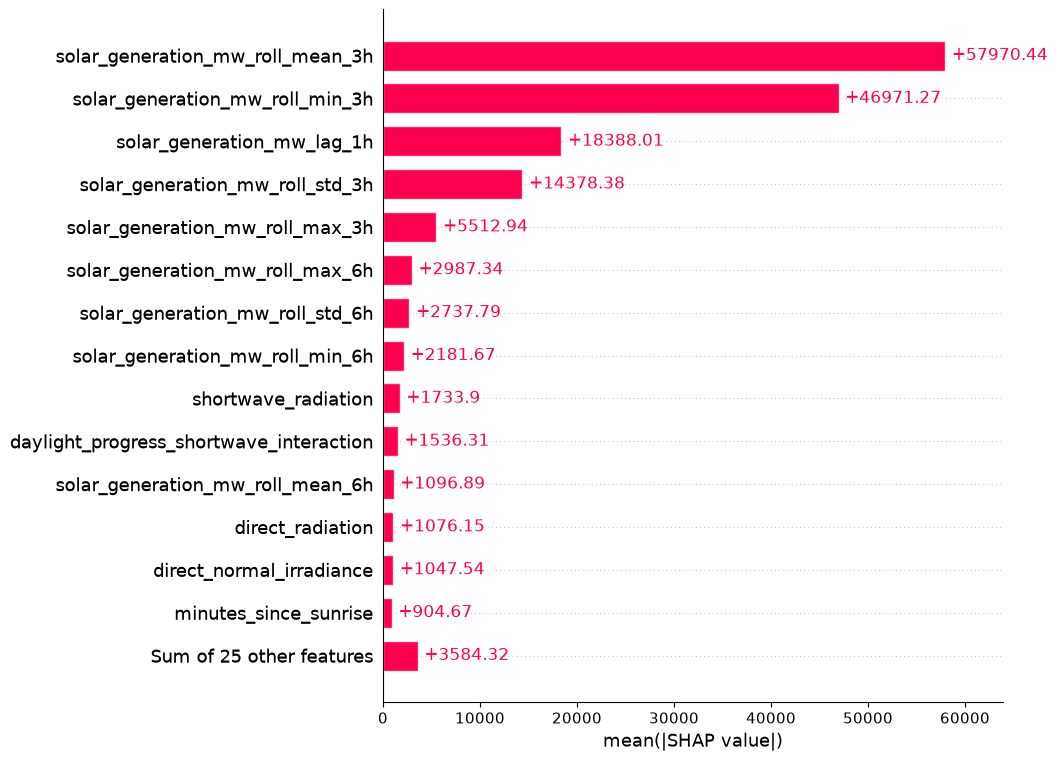

In [31]:
shap.plots.bar(
    shap_values,
    max_display=15
)

### SHAP Beeswarm

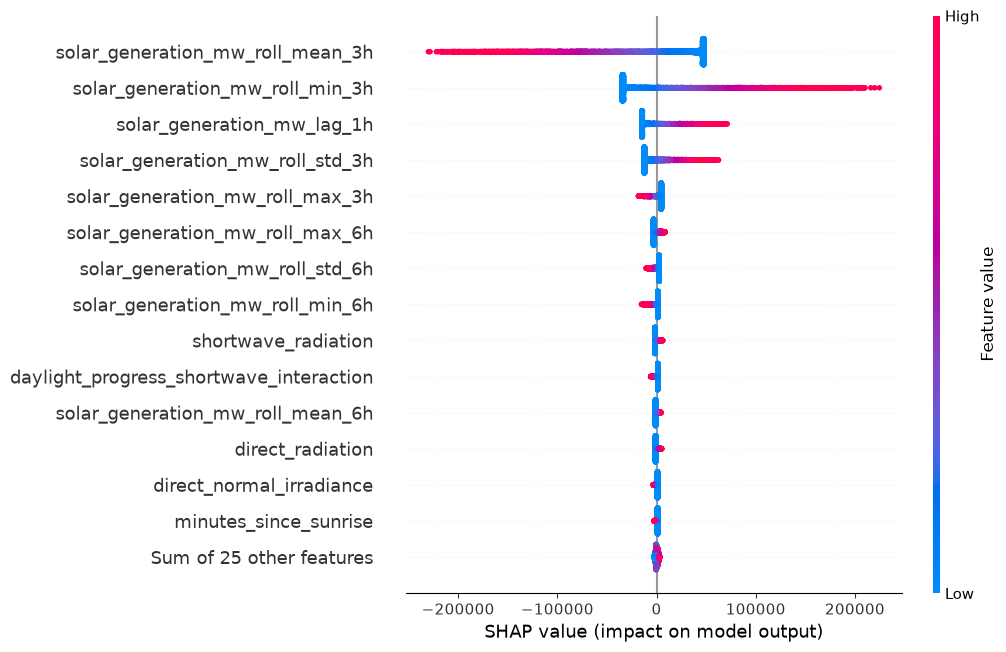

In [32]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

### Dependence Plot

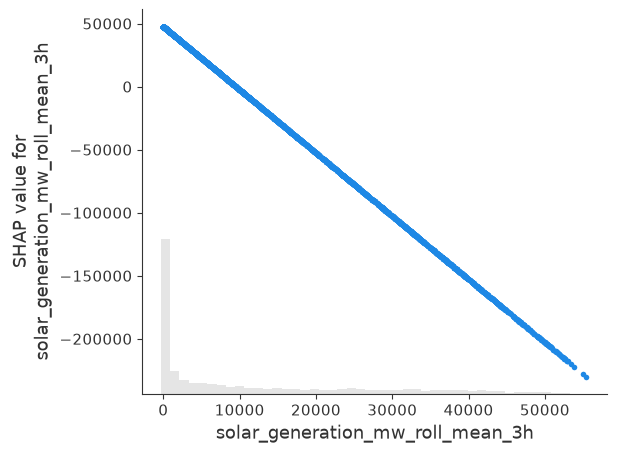

In [48]:
shap.plots.scatter(
    shap_values[:, "solar_generation_mw_roll_mean_3h"]
)

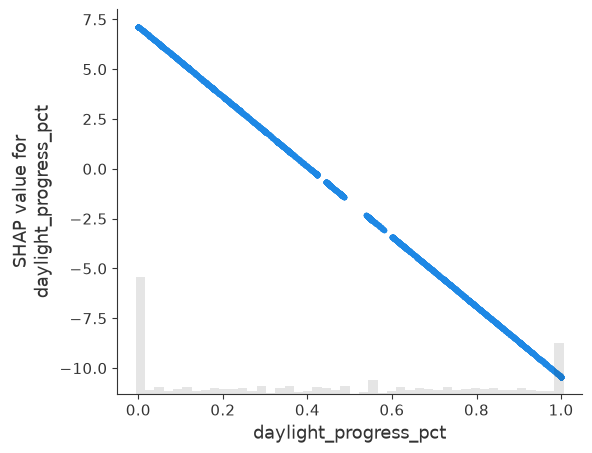

In [44]:
shap.plots.scatter(
    shap_values[:, "daylight_progress_pct"]
)

### Waterfall Plot

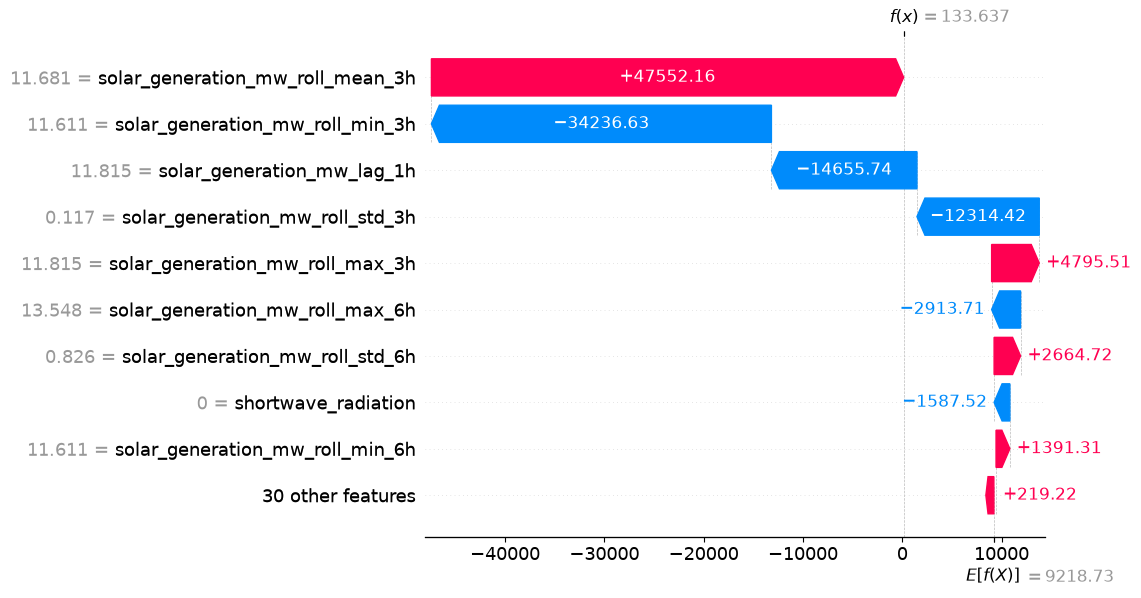

In [45]:
shap.plots.waterfall(
    shap_values[100]
)

In [46]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": production_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

coefficients

,Feature,Coefficient
20,is_daylight,-666.999050
12,hour,149.447538
5,precipitation_mm,-139.834568
18,daylight_duration_hours,110.370407
19,sunshine_duration_hours,21.673482
22,daylight_progress_pct,-17.564151
13,month,17.107131
38,daylight_progress_shortwave_interaction,-14.271735
3,temperature_c,-9.419796
8,shortwave_radiation,8.940983


## Local Prediction Explanation

The waterfall plot decomposes a single prediction into individual feature contributions.

Starting from the model's expected prediction (base value), each feature either increases or decreases the forecast until the final prediction is reached.

Positive SHAP values indicate features that increase predicted solar generation, while negative SHAP values decrease the prediction.

This provides a transparent explanation for individual forecasts and improves model interpretability.

## Conclusion

SHAP analysis demonstrates that the Ridge Regression production model primarily relies on engineered temporal and rolling statistical features, together with daylight and irradiance variables.

The agreement between SHAP feature importance and the learned model coefficients indicates that the model captures physically meaningful relationships rather than relying on spurious correlations.

These findings increase confidence in deploying the forecasting model within the GridSight pipeline.